# Lab 08 — Bias/variance, regularization และ hyperparameter tuning
### Underfitting vs overfitting, L2 / weight decay, dropout, early stopping, search strategies

**กลุ่ม:** C neural network · **อ่านคู่กับสไลด์หน้า:** 81-96, 115-120 · **เวลาโดยประมาณ:** 90 นาที · **Dataset:** nnlab.data.load_moons(n=300, noise=0.35) แบ่งด้วย stratified_split, nnlab.data.get_dataset('churn')

**ควรทำมาก่อน:** Lab 07 (forward/backward ของ network L ชั้น และ class `NeuralNetwork`)

## จุดประสงค์การเรียนรู้
เมื่อทำ lab นี้จบ นิสิตจะสามารถ
1. แยก underfitting (high bias) กับ overfitting (high variance) จาก train/validation accuracy และ cost curve ได้ (สไลด์ p.82)
2. เขียน L2 regularization ลงใน cost และ backward ตามสูตร p.86 และแสดงว่า "weight decay" คือสูตรเดียวกันในอีกรูปหนึ่ง
3. เขียน inverted dropout ด้วย mask และอธิบายได้ว่าทำไมต้องหารด้วย `keep_prob` และทำไมใช้เฉพาะตอนเทรน (p.91-95)
4. ใช้ early stopping กับ validation set (p.96) และอ่านจุดหยุดจาก cost curve ได้
5. จัดลำดับความสำคัญของ hyperparameter (p.116) และทำ random search แบบ log-scale + coarse-to-fine (p.117-120)
6. ใช้ `weight_decay`, `nn.Dropout`, `model.train()/eval()` ของ PyTorch และ `RandomizedSearchCV` ของ scikit-learn ให้ตรงกับที่เขียนเอง

> **วิธีใช้ notebook นี้:** อ่าน markdown cell ก่อน แล้วรัน code cell ถัดไปด้วย `Shift+Enter` ทีละ cell ตามลำดับ
> ทุก code cell มีคำอธิบายว่าทำอะไรและทำไม ถ้าอยากทดลอง ให้แก้ตัวเลขใน cell แล้วรันซ้ำได้เลย

## เตรียมเครื่องมือ
cell แรกของทุก lab จะ import library ที่ใช้ และตั้ง **seed** ให้ตัวเลขสุ่มเหมือนกันทุกครั้งที่รัน
(ไม่งั้นค่าเริ่มต้นของ weight จะต่างกันทุกรอบ และตัวเลขในหน้าจอจะไม่ตรงกับคำอธิบาย)
lab นี้ใช้ PyTorch (เทียบ weight decay และ dropout) และ pandas (ตารางผลการทดลอง) เพิ่มจาก numpy

In [1]:
import numpy as np
import matplotlib.pyplot as plt

try:
    import nnlab                      # package ประกอบ lab (ติดตั้งแล้วด้วย uv sync)
except ImportError:                   # เผื่อเปิดด้วย kernel อื่น: เพิ่ม lab/src เข้า path เอง
    import sys, pathlib
    sys.path.insert(0, str(pathlib.Path.cwd().parent / "src"))
    import nnlab

from nnlab.utils import set_seed
import torch
from torch import nn
import pandas as pd
torch.manual_seed(463)
rng = set_seed(463)                   # 463 = เลขวิชา CP463
np.set_printoptions(precision=4, suppress=True)
%matplotlib inline
print("numpy", np.__version__, "| nnlab", nnlab.__version__)

numpy 2.2.6 | nnlab 0.1.0


## สัญลักษณ์ในบทนี้
| สัญลักษณ์ | ความหมาย | ใน notebook |
|---|---|---|
| training set / dev (validation) set | ข้อมูลที่ใช้ปรับ weight / ข้อมูลที่ใช้ "ส่อง" ว่า overfit หรือยัง (p.96) | `X_tr, y_tr` / `X_val, y_val` |
| $\lambda$ | regularization parameter ของ L2 (p.85) | `l2=` ของ `NeuralNetwork`, `lam` ใน cell |
| $\|W^{[l]}\|_F^2 = \sum_{i}\sum_{j} (w^{[l]}_{ij})^2$ | Frobenius norm กำลังสอง = ผลรวมกำลังสองของทุกช่องใน matrix (p.86) | `np.sum(W ** 2)` |
| $(1 - \frac{\alpha\lambda}{m})$ | ตัวคูณ "weight decay" ที่หด $W$ ทุก epoch (p.86) | `1 - lr * lam / m` |
| keep_prob $= P$ | ความน่าจะเป็นที่ hidden unit จะ **ถูกเปิดใช้** ตอนเทรน (p.91, 93) | `keep_prob=` |
| $D^{[l]}$ | dropout mask 0/1 shape เท่า $A^{[l]}$ | `D = rng.random(A.shape) < keep_prob` |
| patience | จำนวน epoch ที่ยอมให้ val cost ไม่ดีขึ้นก่อนหยุด (early stopping) | `early_stopping_patience=` |
| $\alpha$ | learning rate — hyperparameter ลำดับแรกที่ต้อง tune (p.116) | `lr=` |

## ขั้นที่ 1 · bias กับ variance: ดูจาก train/validation (สไลด์ p.82)
สไลด์ p.82 วาดสามภาพ: **high bias (underfitting)** = boundary ง่ายเกินจนแบ่ง training set เองยังไม่ได้,
**high variance (overfitting)** = boundary ซับซ้อนจนไปจำ noise ของ training set, และ **just right**
ปัญหาคือข้อมูลจริงมีหลายมิติ วาดไม่ได้ — สไลด์จึงบอกว่า "unable to visualize in high dimensional data" เราต้องอ่านจาก **ตัวเลข** แทน:
ถ้า train accuracy ต่ำทั้งคู่ → bias สูง; ถ้า train สูงแต่ validation ต่ำกว่ามาก → variance สูง

เพื่อให้เห็นชัด เราจงใจสร้างสถานการณ์ที่ overfit ง่าย: moons ที่มี noise มาก (0.35) และ **ใช้เทรนแค่ 60 จุด**
ส่วนอีก 240 จุดเก็บเป็น validation set (dev set ในสไลด์ p.96) เอาไว้ส่องว่าโมเดล "จำ" หรือ "เข้าใจ"
`stratified_split(test_ratio=0.2)` คืน (ชุด 80%, ชุด 20%) — เราสลับเอาชุด 20% มาเป็น training โดยตั้งใจ (สังเกตลำดับตัวแปรใน cell)

> **Convention ที่ใช้ในส่วนนี้: library (pandas / scikit-learn / PyTorch)** — `X` มี shape `(m, n_x)` sample เป็น**แถว**, `y` มี shape `(m,)` และ `Z = X @ W.T + b`

training  : (60, 2) | class 1 = 0.5
validation: (240, 2) | class 1 = 0.5  ← สัดส่วน class เท่ากันเพราะ stratified


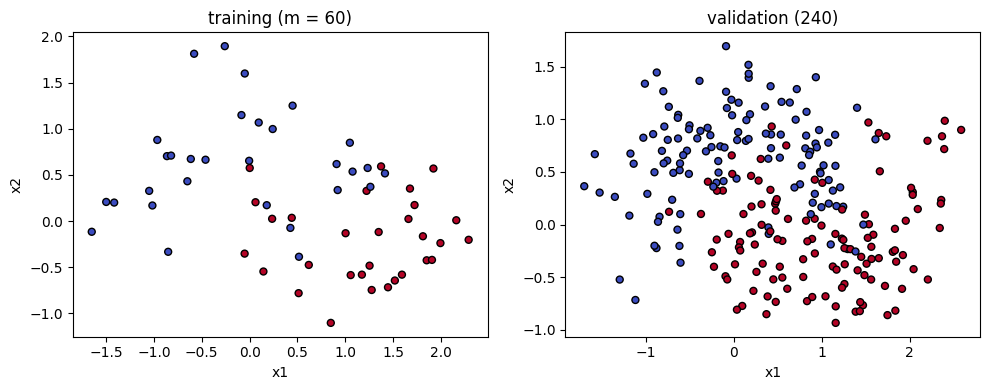

In [2]:
from nnlab.data import load_moons, stratified_split
from nnlab.nn import NeuralNetwork
from nnlab.plotting import plot_decision_boundary, plot_history

X, y = load_moons(n=300, noise=0.35)                      # X: (300, 2) sample เป็นแถว, y: (300,)
X_val, X_tr, y_val, y_tr = stratified_split(X, y, test_ratio=0.2)    # ชุด 20% (60 จุด) → training, ชุด 80% (240 จุด) → validation
m = X_tr.shape[0]
print("training  :", X_tr.shape, "| class 1 =", y_tr.mean())
print("validation:", X_val.shape, "| class 1 =", y_val.mean(), " ← สัดส่วน class เท่ากันเพราะ stratified")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (Xs, ys, name) in zip(axes, [(X_tr, y_tr, "training (m = 60)"), (X_val, y_val, "validation (240)")]):
    ax.scatter(Xs[:, 0], Xs[:, 1], c=ys, cmap="coolwarm", edgecolor="k", s=25)
    ax.set_title(name); ax.set_xlabel("x1"); ax.set_ylabel("x2")
plt.tight_layout(); plt.show()

เทรน network 3 ขนาดด้วย setting เดียวกัน (batch gradient descent, `lr=0.3`, 1500 epoch) แล้วส่ง validation set เข้า `fit` ด้วย
เพื่อให้ `history_["val_cost"]` ถูกบันทึกทุก epoch
- `[2, 1]` = perceptron (เส้นตรง) → คาดว่า underfit: train และ val ต่ำพอๆ กัน
- `[2, 8, 1]` → พอดี: val accuracy สูงสุด
- `[2, 64, 64, 1]` (มี parameter 4,417 ตัว เทียบกับข้อมูล 60 จุด) → overfit: train สูง val ตก และ **val cost กลับขึ้น** ทั้งที่ train cost ยังลง

อ่านตารางก่อนดูรูป แล้วดูรูปเพื่อยืนยันว่าตัวเลขบอกอะไร

In [3]:
configs = {"[2,1] underfit": [2, 1], "[2,8,1] just right": [2, 8, 1], "[2,64,64,1] overfit": [2, 64, 64, 1]}
models, rows = {}, []
for name, sizes in configs.items():
    model = NeuralNetwork(sizes, lr=0.3, epochs=1500).fit(X_tr, y_tr, X_val, y_val)
    models[name] = model
    n_params = sum(v.size for v in model.params_.values())
    rows.append({"model": name, "#params": n_params,
                 "train acc": model.evaluate(X_tr, y_tr)["accuracy"], "val acc": model.evaluate(X_val, y_val)["accuracy"],
                 "train cost": model.history_["cost"][-1], "val cost": model.history_["val_cost"][-1]})
bias_var = pd.DataFrame(rows).round(4)
bias_var

,model,#params,train acc,val acc,train cost,val cost
0,"[2,1] underfit",3,0.8667,0.8208,0.2774,0.3786
1,"[2,8,1] just right",33,0.8667,0.8458,0.1618,0.3958
2,"[2,64,64,1] overfit",4417,0.9667,0.8083,0.1022,0.6392


แถวบน: decision boundary บน training set (จุดที่โมเดลเห็นตอนเทรน) — สังเกตว่า network ใหญ่ลาก boundary หยึกหยักไปเก็บจุด noise ทีละจุด
แถวล่าง: cost ต่อ epoch — ของ network ใหญ่ `val_cost` ลงถึงจุดต่ำสุดตั้งแต่ epoch แรกๆ แล้ว **เด้งขึ้น** ขณะที่ `cost` (train) ลงเรื่อยๆ นี่คือลายเซ็นของ overfitting ที่เราจะใช้ตลอด lab นี้

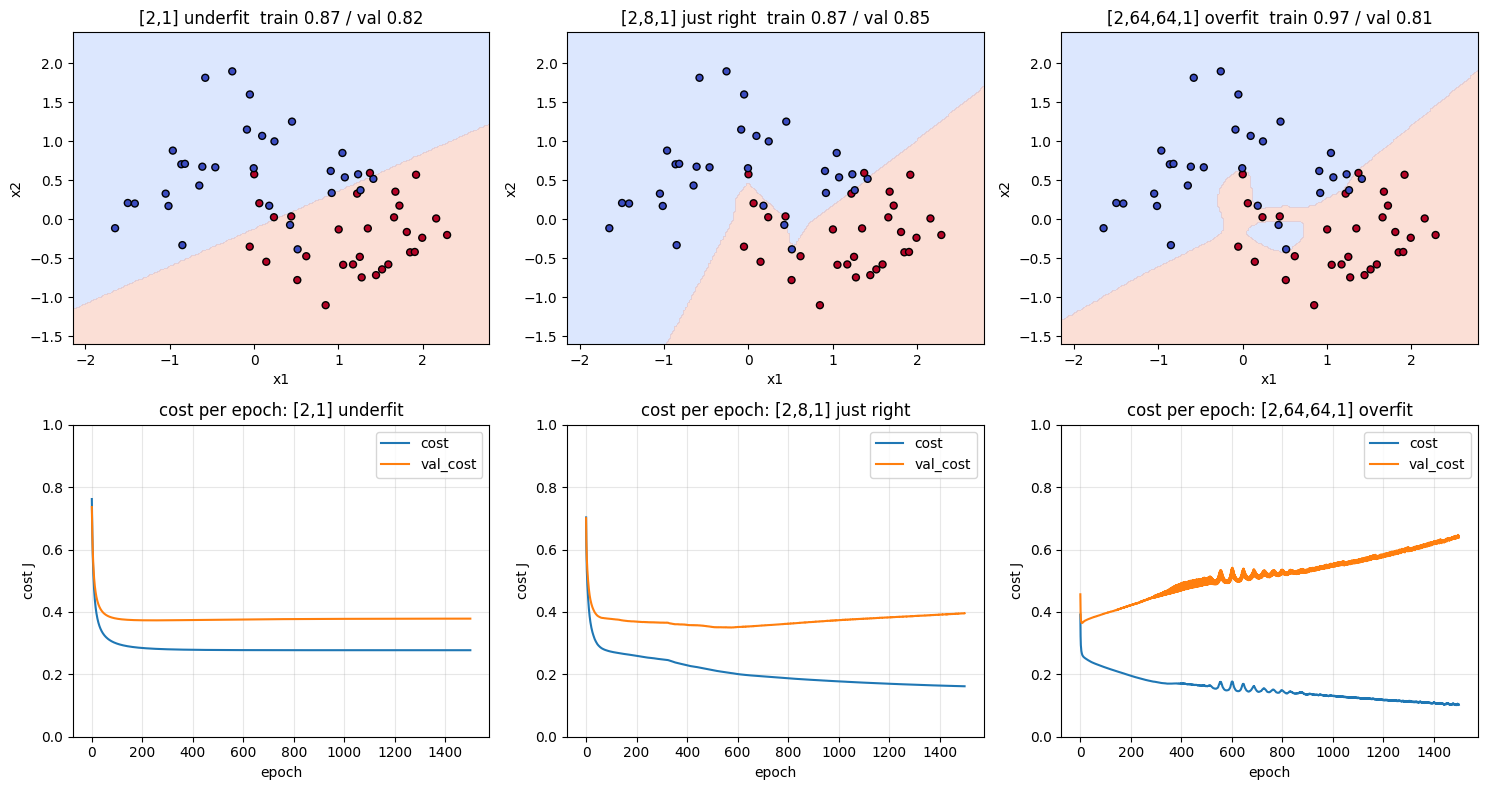

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for j, (name, model) in enumerate(models.items()):
    r = bias_var.iloc[j]
    plot_decision_boundary(model.predict, X_tr, y_tr, ax=axes[0, j], title=f"{name}  train {r['train acc']:.2f} / val {r['val acc']:.2f}")
    plot_history(model.history_, ax=axes[1, j], title=f"cost per epoch: {name}")
    axes[1, j].set_ylim(0, 1.0)
plt.tight_layout(); plt.show()

## ขั้นที่ 2 · L2 regularization และ weight decay (สไลด์ p.84-89)
วิธีแรกที่ใช้ลด variance: **ลงโทษ weight ที่ใหญ่** โดยบวก regularization term เข้าไปใน cost (p.86)
$$\mathcal{J} = \frac{1}{m}\sum_{i=1}^{m}\mathcal{L}(\hat{y}^{(i)}, y^{(i)}) \;+\; \frac{\lambda}{2m}\sum_{l=1}^{L}\|W^{[l]}\|_F^2,
\qquad \|W^{[l]}\|_F^2 = \sum_{i}\sum_{j}\left(w^{[l]}_{ij}\right)^2$$
- Frobenius norm ก็คือ "เอาทุกช่องของ matrix มายกกำลังสองแล้วบวกกัน" — สไลด์ p.85 เรียก $\|w\|_2^2 = w^T w$ ตอนเป็น vector ของ perceptron
- $\lambda$ ใหญ่ → weight ถูกบีบให้เล็ก → $Z^{[l]} = W^{[l]}A^{[l-1]} + b^{[l]}$ เล็ก → activation อยู่ช่วง "เกือบเป็นเส้นตรง" ของ tanh/sigmoid → boundary เรียบขึ้น (p.88)
- ไม่ regularize $b$ (ธรรมเนียมทั่วไป และสไลด์ก็รวมเฉพาะ $W$)
- L1 (p.84) ทำให้ weight หลายตัวเป็นศูนย์พอดี เหมาะกับการบีบอัดโมเดล แต่ใช้น้อยกว่า L2 มาก — lab นี้ทำเฉพาะ L2

cell นี้คำนวณ regularization term ด้วยมือจาก parameter ของ network ใหญ่ที่เพิ่งเทรน แล้วเทียบกับ `nnlab.losses.l2_penalty` และ `nnlab.nn.compute_cost(..., l2=λ)`
ต้องแปลง `X_tr` เป็น deck convention ก่อน เพราะ `forward`/`backward` ระดับล่างรับ $X$ shape $(n_x, m)$

> **Convention ที่ใช้ในส่วนนี้: สไลด์ (deck)** — `X` มี shape `(n_x, m)` sample เป็น**คอลัมน์**, `Y` มี shape `(1, m)`, `w` มี shape `(n_x, 1)` และ `Z = w.T @ X + b`

In [5]:
from nnlab.nn import forward, backward, compute_cost
from nnlab.losses import l2_penalty
from nnlab.conventions import to_deck

X_deck, Y = to_deck(X_tr, y_tr)                            # X_deck: (2, 60), Y: (1, 60)
big = models["[2,64,64,1] overfit"]
params, acts = big.params_, big.activations               # W1 (64,2) b1 (64,1) W2 (64,64) b2 (64,1) W3 (1,64) b3 (1,1)
lam = 0.1

A_L, caches = forward(X_deck, params, acts)               # A_L: (1, 60)
frob = {k: np.sum(v ** 2) for k, v in params.items() if k.startswith("W")}      # ‖W[l]‖²_F ทีละชั้น
penalty = lam / (2 * m) * sum(frob.values())               # (λ/2m) Σ_l ‖W[l]‖²_F
print("‖W[l]‖²_F ทีละชั้น:", {k: round(float(v), 2) for k, v in frob.items()})
print(f"regularization term (λ = {lam}, m = {m}) = {penalty:.4f}")
assert np.isclose(penalty, l2_penalty(params, lam, m))

J_plain = compute_cost(A_L, Y)                            # BCE อย่างเดียว
J_reg = J_plain + penalty
print(f"cost ไม่มี L2 = {J_plain:.4f} | มี L2 = {J_reg:.4f}   (ต่างกัน = regularization term)")
assert np.isclose(J_reg, compute_cost(A_L, Y, params, l2=lam))
print("ตรงกับ nnlab.losses.l2_penalty และ nnlab.nn.compute_cost(l2=λ) ✓")

‖W[l]‖²_F ทีละชั้น: {'W1': 148.37, 'W2': 152.5, 'W3': 22.88}
regularization term (λ = 0.1, m = 60) = 0.2698
cost ไม่มี L2 = 0.1022 | มี L2 = 0.3720   (ต่างกัน = regularization term)
ตรงกับ nnlab.losses.l2_penalty และ nnlab.nn.compute_cost(l2=λ) ✓


### แก้ backward: เพิ่ม $\frac{\lambda}{m}W^{[l]}$ แล้วมองเป็น weight decay (p.86)
อนุพันธ์ของ $\frac{\lambda}{2m}\|W^{[l]}\|_F^2$ เทียบกับ $W^{[l]}$ คือ $\frac{\lambda}{m}W^{[l]}$ (กำลังสองหายไปกับ 2 ในตัวส่วน) ดังนั้น
$$dW^{[l]} = (\text{term จาก backward เดิม}) + \frac{\lambda}{m}W^{[l]}$$
แทนลงใน gradient descent แล้วจัดรูปใหม่ตามสไลด์:
$$W^{[l]} := W^{[l]} - \alpha\,dW^{[l]} = \left(1 - \frac{\alpha\lambda}{m}\right)W^{[l]} - \alpha\,(\text{term เดิม})$$
ตัวคูณ $(1 - \frac{\alpha\lambda}{m}) < 1$ หด $W$ ลงนิดหนึ่ง**ทุก epoch** ก่อนจะลบ gradient ปกติ — จึงเรียก **weight decay**
cell นี้ทำทั้งสองรูปกับ $W^{[1]}$ หนึ่งก้าว แล้ว `assert` ว่าได้ตัวเลขเดียวกัน และเทียบกับ `backward(..., l2=λ)` ของ nnlab

In [6]:
lr = 0.3
grads = backward(Y, caches, params, acts)                 # backward เดิม (ไม่มี L2): dW1 (64, 2)
dW1_reg = grads["dW1"] + (lam / m) * params["W1"]         # รูปที่ 1: บวก (λ/m) W  (64, 2)

W1_form1 = params["W1"] - lr * dW1_reg                                     # W := W − α dW
W1_form2 = (1 - lr * lam / m) * params["W1"] - lr * grads["dW1"]           # W := (1 − αλ/m) W − α·(term เดิม)
assert np.allclose(W1_form1, W1_form2)
print(f"ตัวคูณ weight decay (1 − αλ/m) = 1 − {lr}·{lam}/{m} = {1 - lr * lam / m:.5f}")
print("รูป 'บวก (λ/m)W ใน dW' กับรูป 'weight decay' ให้ W1 ใหม่เท่ากันทุกช่อง ✓")

grads_lib = backward(Y, caches, params, acts, l2=lam)     # nnlab ใส่ (λ/m) W ให้ใน backward
assert np.allclose(grads_lib["dW1"], dW1_reg) and np.allclose(grads_lib["db1"], grads["db1"])
print("nnlab.nn.backward(l2=λ): dW ตรงกับที่เราบวกเอง และ db ไม่เปลี่ยน (ไม่ regularize bias) ✓")
print("ขนาด gradient จาก L2 เทียบกับ term เดิม:", f"{np.abs((lam / m) * params['W1']).mean():.4f} vs {np.abs(grads['dW1']).mean():.4f}")

ตัวคูณ weight decay (1 − αλ/m) = 1 − 0.3·0.1/60 = 0.99950
รูป 'บวก (λ/m)W ใน dW' กับรูป 'weight decay' ให้ W1 ใหม่เท่ากันทุกช่อง ✓
nnlab.nn.backward(l2=λ): dW ตรงกับที่เราบวกเอง และ db ไม่เปลี่ยน (ไม่ regularize bias) ✓
ขนาด gradient จาก L2 เทียบกับ term เดิม: 0.0015 vs 0.0074


### ผลของ $\lambda$ ต่อ network ใหญ่
เทรน `[2, 64, 64, 1]` ซ้ำด้วย `l2` หลายค่า (setting อื่นเหมือนขั้นที่ 1) แล้วดู 3 อย่างพร้อมกัน
1. norm ของ $W$ แต่ละชั้น **เล็กลง** เมื่อ $\lambda$ เพิ่ม (นี่คือสิ่งที่ weight decay ทำโดยตรง)
2. validation accuracy **ดีขึ้น** จนถึงจุดหนึ่ง แล้วถ้า $\lambda$ ใหญ่เกิน train accuracy จะเริ่มตก (กลับไป bias สูง — p.87 ลูกศร $\lambda\uparrow$)
3. val cost curve **เรียบขึ้น** และไม่เด้งขึ้นแรงเท่าเดิม (p.89 "smoother cost function")

In [7]:
l2_values = [0.0, 0.01, 0.1, 0.3, 1.0]
l2_models, rows = {}, []
for lam_i in l2_values:
    model = NeuralNetwork([2, 64, 64, 1], lr=0.3, epochs=1500, l2=lam_i).fit(X_tr, y_tr, X_val, y_val)
    l2_models[lam_i] = model
    norms = {f"‖{k}‖": np.linalg.norm(v) for k, v in model.params_.items() if k.startswith("W")}
    rows.append({"l2 (λ)": lam_i, **norms, "train acc": model.evaluate(X_tr, y_tr)["accuracy"],
                 "val acc": model.evaluate(X_val, y_val)["accuracy"], "val cost": model.history_["val_cost"][-1]})
l2_table = pd.DataFrame(rows).round(3)
l2_table

,l2 (λ),‖W1‖,‖W2‖,‖W3‖,train acc,val acc,val cost
0,0.00,12.181,12.349,4.783,0.967,0.808,0.639
1,0.01,11.422,11.550,4.750,0.967,0.812,0.605
2,0.10,6.740,6.678,4.244,0.967,0.842,0.437
3,0.30,3.391,3.378,3.160,0.900,0.846,0.352
4,1.00,2.114,2.131,2.158,0.900,0.825,0.360


รูปซ้าย-กลาง: boundary ของ $\lambda = 0$ กับ $\lambda = 0.1$ บน training set — เส้นเรียบขึ้นและเลิกวนเก็บจุด noise
รูปขวา: val cost ของทุก $\lambda$ — ยิ่ง $\lambda$ มาก เส้นยิ่งเรียบและต่ำกว่า (แต่ $\lambda = 1$ เริ่มสูงกว่า 0.3 เพราะ underfit)

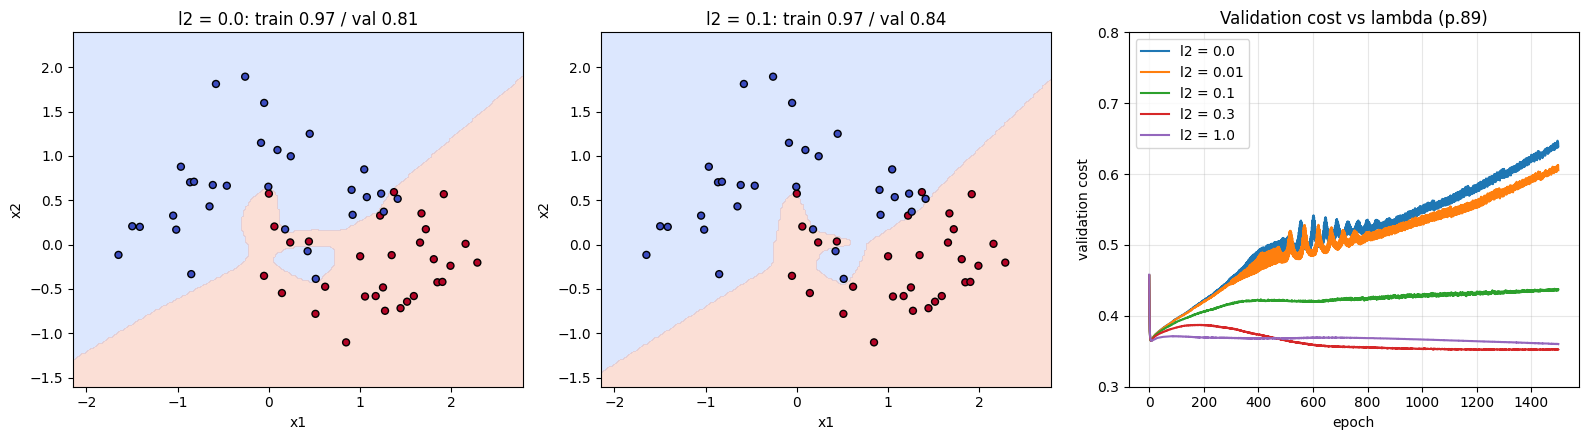

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, lam_i in zip(axes[:2], [0.0, 0.1]):
    r = l2_table[l2_table["l2 (λ)"] == lam_i].iloc[0]
    plot_decision_boundary(l2_models[lam_i].predict, X_tr, y_tr, ax=ax, title=f"l2 = {lam_i}: train {r['train acc']:.2f} / val {r['val acc']:.2f}")
for lam_i, model in l2_models.items():
    axes[2].plot(model.history_["val_cost"], label=f"l2 = {lam_i}")
axes[2].set_xlabel("epoch"); axes[2].set_ylabel("validation cost"); axes[2].set_ylim(0.3, 0.8); axes[2].legend(); axes[2].grid(alpha=0.3)
axes[2].set_title("Validation cost vs lambda (p.89)")
plt.tight_layout(); plt.show()

### numpy | torch: `weight_decay` ของ `torch.optim.SGD`
PyTorch ไม่ได้บวก regularization term เข้า loss แต่ให้ optimizer **บวก `weight_decay · W` เข้า gradient** ก่อนอัปเดต:
`W := W − lr · (grad + weight_decay · W)` — รูปเดียวกับสไลด์ p.86 แต่ตัวคูณคือ `weight_decay` ตรงๆ ไม่ใช่ $\frac{\lambda}{m}$
ดังนั้นถ้าอยากได้ผลเท่ากับ `NeuralNetwork(l2=λ)` ต้องตั้ง `weight_decay = λ / m` (และ torch จะ decay bias ด้วยถ้าไม่แยก parameter group — ต่างจาก nnlab ที่ไม่แตะ $b$)

cell นี้ copy parameter ของ network ใหญ่เข้า `nn.Sequential` (วิธีเดียวกับ lab07) ทำ backward หนึ่งครั้ง แล้ว `SGD(weight_decay=λ/m).step()` หนึ่งก้าว
จากนั้นเทียบ $W^{[1]}$ ใหม่กับสูตร numpy ที่เราเพิ่งพิสูจน์ — ต้องเท่ากันถึงหลักที่ 10

> **Convention ที่ใช้ในส่วนนี้: library (pandas / scikit-learn / PyTorch)** — `X` มี shape `(m, n_x)` sample เป็น**แถว**, `y` มี shape `(m,)` และ `Z = X @ W.T + b`

In [9]:
tmodel = nn.Sequential(nn.Linear(2, 64), nn.ReLU(), nn.Linear(64, 64), nn.ReLU(), nn.Linear(64, 1)).double()
linears = [layer for layer in tmodel if isinstance(layer, nn.Linear)]
with torch.no_grad():
    for l, lin in enumerate(linears, start=1):
        lin.weight.copy_(torch.tensor(params[f"W{l}"]))          # weight (n_out, n_in) = W[l] (n[l], n[l-1])
        lin.bias.copy_(torch.tensor(params[f"b{l}"].ravel()))    # bias (n_out,) = b[l] (n[l], 1) บีบเป็น 1 มิติ

X_t, y_t = torch.tensor(X_tr), torch.tensor(y_tr, dtype=torch.float64)    # X_t: (60, 2) sample เป็นแถว
wd = lam / m                                                              # weight_decay ที่เทียบเท่า λ ของสไลด์
opt = torch.optim.SGD(tmodel.parameters(), lr=lr, weight_decay=wd)
opt.zero_grad()
loss = nn.BCEWithLogitsLoss()(tmodel(X_t).squeeze(1), y_t)              # loss = BCE เฉลี่ย m sample (ไม่มี L2 ใน loss!)
loss.backward()
print(f"loss ของ torch = {loss.item():.6f} = cost ไม่มี L2 ของ numpy {J_plain:.6f} → torch ไม่ได้บวก penalty ใน loss")
assert np.allclose(linears[0].weight.grad.numpy(), grads["dW1"])          # grad ของ torch = term เดิม (ไม่มี (λ/m)W)
opt.step()                                                                # W := W − lr·(grad + wd·W)

W1_torch = linears[0].weight.detach().numpy()                             # (64, 2)
print("W1 หลัง 1 ก้าวของ torch == (1 − lr·λ/m)·W1 − lr·dW1 ของ numpy:", np.allclose(W1_torch, W1_form2, atol=1e-10))
assert np.allclose(W1_torch, W1_form2, atol=1e-10)
print(f"ถ้าตั้ง weight_decay = λ = {lam} ตรงๆ (ลืมหาร m) ตัวคูณจะเป็น {1 - lr * lam:.3f} แทน {1 - lr * lam / m:.5f} → หดแรงกว่า {m} เท่า")

loss ของ torch = 0.102165 = cost ไม่มี L2 ของ numpy 0.102165 → torch ไม่ได้บวก penalty ใน loss
W1 หลัง 1 ก้าวของ torch == (1 − lr·λ/m)·W1 − lr·dW1 ของ numpy: True
ถ้าตั้ง weight_decay = λ = 0.1 ตรงๆ (ลืมหาร m) ตัวคูณจะเป็น 0.970 แทน 0.99950 → หดแรงกว่า 60 เท่า


## ขั้นที่ 3 · dropout (สไลด์ p.91-95)
วิธีที่สอง: ตอนเทรน **สุ่มปิด hidden unit** ในแต่ละชั้นด้วยความน่าจะเป็น $1 - P$ (สไลด์ใช้ $P$ = keepprob = ความน่าจะเป็นที่ unit จะ**เปิด**)
ทุก iteration ได้ network "คนละตัว" — เหมือนเทรน ensemble ของ network เล็กๆ หลายตัวพร้อมกัน (p.91) และ unit ไหนก็พึ่งเพื่อนตัวใดตัวหนึ่งไม่ได้ จึงต้องกระจาย weight

วิธีทำตาม p.93-94 (เรียกว่า **inverted dropout**):
1. สร้าง mask $D^{[l]}$ 0/1 shape เท่า $A^{[l]}$: `D = rng.random(A.shape) < keep_prob`
2. ปิด unit: `A = A * D`
3. **หารด้วย keep_prob**: `A = A / keep_prob` — เพื่อให้ค่าคาดหวังของ $A^{[l]}$ เท่าเดิม (ปิดไปครึ่งหนึ่ง ที่เหลือต้องดังขึ้นสองเท่า) ชั้นถัดไปจะได้ไม่เจอค่า $Z$ ที่เล็กลงผิดปกติ
4. ตอน test **ไม่ทำอะไรเลย** (p.91 "applied ONLY training but NOT testing") — เพราะข้อ 3 ทำให้ scale ตรงกันอยู่แล้ว

หมายเหตุสไลด์: p.92-94 ใช้หัวข้อ "DropConnect" (สุ่มปิด**เส้นเชื่อม**) แต่โค้ดที่อธิบายใน p.93-94 คือการปิด**หน่วย** $a^{[3]}$ ด้วย keepprob ซึ่งคือ dropout ตามปกติ — เราทำตามโค้ด
cell นี้ใช้ $A^{[1]}$ shape $(64, 60)$ จาก `caches` ของ network ใหญ่ แสดง mask และพิสูจน์เรื่องค่าเฉลี่ยด้วยตัวเลข

> **Convention ที่ใช้ในส่วนนี้: สไลด์ (deck)** — `X` มี shape `(n_x, m)` sample เป็น**คอลัมน์**, `Y` มี shape `(1, m)`, `w` มี shape `(n_x, 1)` และ `Z = w.T @ X + b`

In [10]:
A1 = caches[0]["A"]                                        # A[1]: (64, 60) หลัง ReLU
keep_prob = 0.5
D1 = rng.random(A1.shape) < keep_prob                      # D[1]: (64, 60) True = เปิด (สัดส่วน ≈ keep_prob)
A1_off = A1 * D1                                           # ปิด unit อย่างเดียว → ค่าเฉลี่ยหายไปครึ่ง
A1_drop = A1 * D1 / keep_prob                              # inverted dropout → ค่าเฉลี่ยกลับมาเท่าเดิม (โดยประมาณ)

print("mask 5×8 ช่องแรก:\n", D1[:5, :8].astype(int))
print(f"สัดส่วน unit ที่เปิด = {D1.mean():.3f}   (คาดว่า ≈ {keep_prob})")
print(f"mean(A1) = {A1.mean():.4f} | ปิดเฉยๆ mean = {A1_off.mean():.4f} (≈ ครึ่ง) | หาร keep_prob แล้ว mean = {A1_drop.mean():.4f} (≈ เท่าเดิม)")
print("ช่องที่ mask ปิด:", int((~D1).sum()), "จาก", A1.size, "| ช่องที่เป็นศูนย์อยู่แล้วเพราะ ReLU:", int((A1 == 0).sum()))

# เวอร์ชันใน nnlab.nn.forward: ส่ง training=True, keep_prob, rng → mask ถูกเก็บใน caches[l-1]["D"] ให้ backward ใช้
_, caches_drop = forward(X_deck, params, acts, keep_prob=keep_prob, training=True, rng=rng)
print("\nnnlab forward(training=True): mask ชั้น 1 shape", caches_drop[0]["D"].shape, "| เปิด", round(caches_drop[0]["D"].mean(), 3),
      "| ชั้น output ไม่ dropout:", caches_drop[-1]["D"] is None)

mask 5×8 ช่องแรก:
 [[0 1 1 0 0 1 1 0]
 [0 1 1 1 1 1 1 0]
 [0 0 1 0 1 1 1 1]
 [0 0 0 1 0 1 0 1]
 [1 1 0 0 1 1 0 0]]
สัดส่วน unit ที่เปิด = 0.496   (คาดว่า ≈ 0.5)
mean(A1) = 0.4436 | ปิดเฉยๆ mean = 0.2105 (≈ ครึ่ง) | หาร keep_prob แล้ว mean = 0.4209 (≈ เท่าเดิม)
ช่องที่ mask ปิด: 1934 จาก 3840 | ช่องที่เป็นศูนย์อยู่แล้วเพราะ ReLU: 2017

nnlab forward(training=True): mask ชั้น 1 shape (64, 60) | เปิด 0.49 | ชั้น output ไม่ dropout: True


ใน backward ต้องส่ง gradient ผ่านเฉพาะ unit ที่เปิด (คูณ mask ตัวเดิมและหาร `keep_prob` เหมือนตอน forward) — `nnlab.nn.backward` ทำให้แล้ว
ตอนนี้เทรนจริง: `NeuralNetwork(keep_prob=...)` ใช้ dropout ทุก iteration ตอนเทรน แต่ตอน `predict`/วัด cost ปิด dropout ตามข้อ 4
คาดว่า `keep_prob=0.5` จะทำให้ train accuracy ลดลงนิดหน่อยแต่ validation ดีขึ้น และ boundary เรียบกว่า `keep_prob=1.0` (ไม่ใช้ dropout)

> **Convention ที่ใช้ในส่วนนี้: library (pandas / scikit-learn / PyTorch)** — `X` มี shape `(m, n_x)` sample เป็น**แถว**, `y` มี shape `(m,)` และ `Z = X @ W.T + b`

 keep_prob  train acc  val acc  val cost
       1.0      0.967    0.808     0.639
       0.8      0.933    0.829     0.586
       0.5      0.933    0.850     0.508


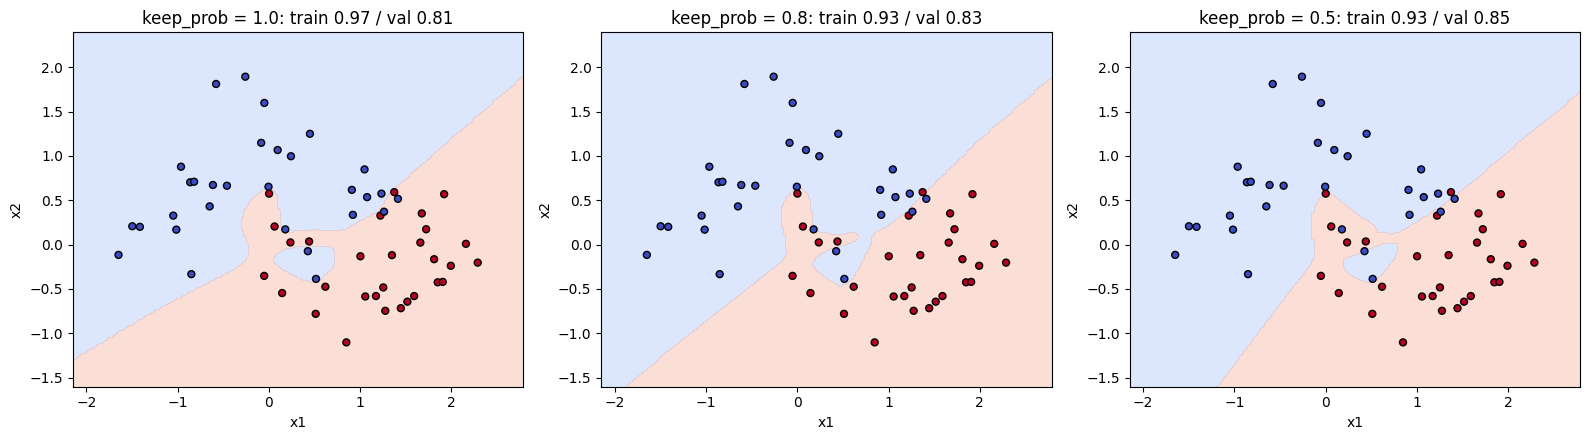

In [11]:
drop_models, rows = {}, []
for kp in [1.0, 0.8, 0.5]:
    model = NeuralNetwork([2, 64, 64, 1], lr=0.3, epochs=1500, keep_prob=kp).fit(X_tr, y_tr, X_val, y_val)
    drop_models[kp] = model
    rows.append({"keep_prob": kp, "train acc": model.evaluate(X_tr, y_tr)["accuracy"],
                 "val acc": model.evaluate(X_val, y_val)["accuracy"], "val cost": model.history_["val_cost"][-1]})
drop_table = pd.DataFrame(rows).round(3)
print(drop_table.to_string(index=False))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, (kp, model) in zip(axes, drop_models.items()):
    r = drop_table[drop_table["keep_prob"] == kp].iloc[0]
    plot_decision_boundary(model.predict, X_tr, y_tr, ax=ax, title=f"keep_prob = {kp}: train {r['train acc']:.2f} / val {r['val acc']:.2f}")
plt.tight_layout(); plt.show()

### numpy | torch: `nn.Dropout` กับ `model.train()` / `model.eval()`
torch ระบุ `p` = ความน่าจะเป็นที่จะ**ปิด** = `1 − keep_prob` (กลับด้านกับสไลด์ — จุดที่คนสับสนบ่อยที่สุด)
และใช้ inverted dropout เหมือนเรา: ค่าที่รอดถูกคูณ $\frac{1}{1-p}$
โมเดลของ torch มี 2 โหมด: `.train()` เปิด dropout (สุ่มใหม่ทุกครั้งที่เรียก) และ `.eval()` ปิด dropout (คืนค่าเดิมเป๊ะ) — ลืมสลับโหมดตอน predict คือ bug คลาสสิก
cell นี้ป้อน $A^{[1]}$ ตัวเดิม (transpose เป็นแถว) เข้า `nn.Dropout(p=0.5)` ทั้งสองโหมด

In [12]:
drop = nn.Dropout(p=1 - keep_prob)                          # p = ความน่าจะเป็นที่ "ปิด" = 0.5
a1 = torch.tensor(A1.T)                                     # (60, 64) sample เป็นแถว

drop.train()                                                # โหมดเทรน: สุ่ม mask
out_train = drop(a1)
nonzero = a1 != 0                                           # นับเฉพาะช่องที่ไม่ใช่ศูนย์อยู่แล้วจาก ReLU
zeros = ((out_train == 0) & nonzero).sum().item() / nonzero.sum().item()
print(f"train mode: สัดส่วนช่อง (ที่เดิมไม่ใช่ 0) ถูกปิดเป็น 0 = {zeros:.3f} (≈ p) | mean เดิม {a1.mean():.4f} → mean หลัง dropout {out_train.mean():.4f} (scale ด้วย 1/(1-p) = {1 / (1 - drop.p):.1f})")
print("เรียกซ้ำได้ mask ใหม่ (ค่าไม่เท่าเดิม):", not torch.equal(out_train, drop(a1)))

drop.eval()                                                 # โหมด test: ไม่ทำอะไร
out_eval = drop(a1)
print("eval mode: output == input ทุกช่อง:", torch.equal(out_eval, a1))
print("\nสรุป: numpy `A * D / keep_prob` ตอนเทรน + ไม่ทำอะไรตอน test  ==  torch `nn.Dropout(p=1-keep_prob)` + `.train()`/`.eval()`")

train mode: สัดส่วนช่อง (ที่เดิมไม่ใช่ 0) ถูกปิดเป็น 0 = 0.492 (≈ p) | mean เดิม 0.4436 → mean หลัง dropout 0.4593 (scale ด้วย 1/(1-p) = 2.0)
เรียกซ้ำได้ mask ใหม่ (ค่าไม่เท่าเดิม): True
eval mode: output == input ทุกช่อง: True

สรุป: numpy `A * D / keep_prob` ตอนเทรน + ไม่ทำอะไรตอน test  ==  torch `nn.Dropout(p=1-keep_prob)` + `.train()`/`.eval()`


## ขั้นที่ 4 · early stopping (สไลด์ p.96)
วิธีที่สามไม่แตะ cost เลย: เฝ้าดู **validation cost** ทุก epoch แล้ว **หยุดเมื่อมันเลิกลง** (p.96 กราฟ training set ลงเรื่อยๆ แต่ dev set ตีกลับ)
กติกาที่ใช้กันจริง: เก็บ parameter ชุดที่ val cost ต่ำสุดไว้ ถ้าผ่านไป `patience` epoch แล้วยังไม่มีค่าที่ต่ำกว่านั้น → หยุด และ **คืน parameter ชุดที่ดีที่สุด** (ไม่ใช่ชุดสุดท้าย)

`NeuralNetwork(early_stopping_patience=25)` ทำแบบนี้ (ต้องส่ง `X_val, y_val` ให้ `fit`) หลังหยุดจะมี attribute `stopped_epoch_`
เราลด `lr` เป็น 0.1 ให้ val cost เด้งขึ้นช้าลงหน่อยจะได้เห็นเป็นเส้นโค้ง (ที่ `lr=0.3` จุดต่ำสุดอยู่ที่ epoch 7 — เร็วมาก)
cell นี้เทรนสองครั้ง: แบบไม่หยุด (1500 epoch เพื่อวาดเส้นเต็ม) และแบบ early stopping แล้ววาดจุดหยุดทับบนกราฟ

ไม่หยุด   : 1500 epoch  val cost ต่ำสุด 0.3639 ที่ epoch 22 → จบที่ 0.4743  train acc 0.950 / val acc 0.812
early stop: หยุดที่ epoch 47 (= 22 + patience 25)  คืน parameter ของ epoch 22  train acc 0.900 / val acc 0.817


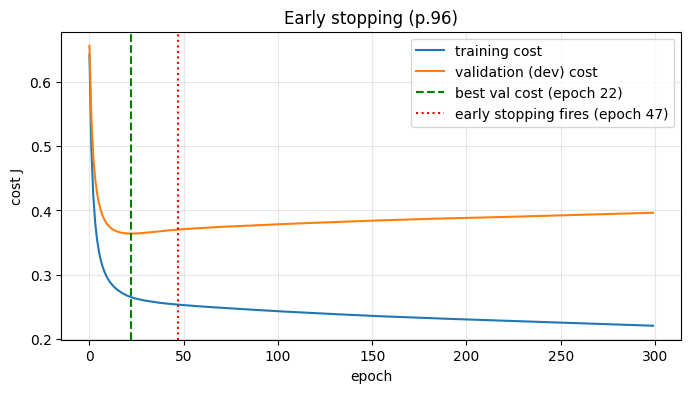

In [13]:
patience = 25
full = NeuralNetwork([2, 64, 64, 1], lr=0.1, epochs=1500).fit(X_tr, y_tr, X_val, y_val)
es = NeuralNetwork([2, 64, 64, 1], lr=0.1, epochs=1500, early_stopping_patience=patience).fit(X_tr, y_tr, X_val, y_val)

val_full = np.array(full.history_["val_cost"])
best_epoch = int(val_full.argmin())
print(f"ไม่หยุด   : 1500 epoch  val cost ต่ำสุด {val_full.min():.4f} ที่ epoch {best_epoch} → จบที่ {val_full[-1]:.4f}  "
      f"train acc {full.evaluate(X_tr, y_tr)['accuracy']:.3f} / val acc {full.evaluate(X_val, y_val)['accuracy']:.3f}")
print(f"early stop: หยุดที่ epoch {es.stopped_epoch_} (= {best_epoch} + patience {patience})  คืน parameter ของ epoch {best_epoch}  "
      f"train acc {es.evaluate(X_tr, y_tr)['accuracy']:.3f} / val acc {es.evaluate(X_val, y_val)['accuracy']:.3f}")

fig, ax = plt.subplots(figsize=(8, 4))
show = 300                                                  # ดูแค่ 300 epoch แรกให้เห็นจุดหักชัดๆ
ax.plot(full.history_["cost"][:show], label="training cost")
ax.plot(val_full[:show], label="validation (dev) cost")
ax.axvline(best_epoch, color="green", ls="--", label=f"best val cost (epoch {best_epoch})")
ax.axvline(es.stopped_epoch_, color="red", ls=":", label=f"early stopping fires (epoch {es.stopped_epoch_})")
ax.set_xlabel("epoch"); ax.set_ylabel("cost J"); ax.set_title("Early stopping (p.96)"); ax.legend(); ax.grid(alpha=0.3)
plt.show()

สังเกต: training cost ลงตลอด แต่ validation cost ต่ำสุดตั้งแต่ epoch ยี่สิบกว่าๆ แล้วค่อยๆ ขึ้น — early stopping จับจังหวะนี้ให้อัตโนมัติโดยไม่ต้องรู้ $\lambda$ หรือ keep_prob
ข้อเสีย (ที่ Andrew Ng พูดถึง): มันผูก "ลด cost" กับ "ลด overfitting" ไว้ในปุ่มเดียว — ปรับแยกกันไม่ได้เหมือน L2 ในทางปฏิบัติมักใช้ร่วมกับ L2/dropout

## ขั้นที่ 5 · hyperparameter tuning (สไลด์ p.115-120)
ทุกอย่างที่เราเลือกเอง (ไม่ได้เรียนจากข้อมูล) คือ hyperparameter: $\alpha$, $\lambda$, keep_prob, จำนวนชั้น, จำนวน unit, mini-batch size, $\beta$ ของ optimizer …
สไลด์ p.116 จัดลำดับความสำคัญไว้ — เริ่ม tune ตัวสำคัญก่อนเสมอ

| ลำดับ | hyperparameter | หมายเหตุ |
|---|---|---|
| 1 | $\alpha$ learning rate | สำคัญที่สุด — ผิดแล้วอย่างอื่นช่วยไม่ได้ (ดู lab09) |
| 2 | mini-batch size, $n^{[l]}$ จำนวน hidden unit, $\beta$ ของ momentum | |
| 3 | $L$ จำนวนชั้น, learning rate decay | |
| แทบไม่ต้อง | $\beta_1, \beta_2, \varepsilon$ ของ Adam | ใช้ค่า default 0.9 / 0.999 / $10^{-8}$ (p.114) |

**grid vs random (p.117-118):** ถ้าลอง 2 hyperparameter อย่างละ 5 ค่าแบบตาราง (grid) = 25 การทดลอง แต่ได้เห็น $\alpha$ แค่ 5 ค่า
ถ้าสุ่ม 25 จุด (random) จะได้เห็น $\alpha$ 25 ค่าที่ต่างกันหมด — คุ้มกว่าเมื่อ hyperparameter บางตัวสำคัญกว่าตัวอื่นมาก (ซึ่งเป็นกรณีปกติใน deep learning)

cell นี้ทำ random search เล็กๆ บน churn dataset (ข้อมูลลูกค้า 1,000 คน 6 feature หลัง one-hot, แบ่ง 800/200 และ normalize แล้วโดย `get_dataset`)
สุ่ม `lr` แบบ log-scale `10 ** rng.uniform(-3, 0)` (เหตุผลอยู่ cell ถัดไป) และจำนวน hidden unit 4-64 รวม 12 ชุด เทรนสั้นๆ 150 epoch ด้วย adam แล้วเรียงตาม validation accuracy

In [14]:
from nnlab.data import get_dataset

X_tr_c, X_val_c, y_tr_c, y_val_c, _ = get_dataset("churn")           # (800, 6) / (200, 6) normalize แล้ว
n_x = X_tr_c.shape[1]
majority = max(y_val_c.mean(), 1 - y_val_c.mean())
print(f"churn: train {X_tr_c.shape} val {X_val_c.shape} | churn rate = {y_tr_c.mean():.3f} → ทายว่า 'ไม่ churn' ทุกคนได้ accuracy {majority:.3f} (baseline)")

rows = []
for trial in range(12):
    lr_i = 10 ** rng.uniform(-3, 0)                                    # log-uniform ระหว่าง 0.001 ถึง 1
    hidden = int(rng.integers(4, 65))                                  # 4..64 unit (linear scale)
    model = NeuralNetwork([n_x, hidden, 1], lr=lr_i, epochs=150, optimizer="adam", batch_size=64).fit(X_tr_c, y_tr_c)
    rows.append({"trial": trial, "lr": lr_i, "hidden": hidden,
                 "train acc": model.evaluate(X_tr_c, y_tr_c)["accuracy"], "val acc": model.evaluate(X_val_c, y_val_c)["accuracy"]})
search = pd.DataFrame(rows).sort_values("val acc", ascending=False).reset_index(drop=True)
search.round(4)

churn: train (800, 6) val (200, 6) | churn rate = 0.311 → ทายว่า 'ไม่ churn' ทุกคนได้ accuracy 0.690 (baseline)


,trial,lr,hidden,train acc,val acc
0,2,0.0031,22,0.7388,0.760
1,5,0.0059,35,0.7588,0.760
2,10,0.0023,55,0.7562,0.760
3,3,0.0036,32,0.7438,0.745
4,6,0.0016,54,0.7538,0.745
5,7,0.0653,53,0.7525,0.740
6,4,0.0052,32,0.7600,0.735
7,1,0.1306,39,0.7438,0.725
8,0,0.1235,60,0.7475,0.720
9,9,0.1929,57,0.7462,0.715


อ่านตาราง: `lr` ระดับ 0.002-0.01 ครองแถวบน ส่วน `lr` ระดับ 0.1-0.5 อยู่แถวล่าง (ถ้า `lr` ใหญ่ถึง ~0.5-1 adam มักกระโดดจน weight พัง ได้ `val acc` เท่ากับ baseline พอดี = **ทาย class เดียวทั้งหมด**)
จำนวน hidden unit มีผลน้อยกว่า `lr` มาก — ตรงกับลำดับความสำคัญของ p.116 · หมายเหตุ: churn สังเคราะห์นี้มีเพดานราว 0.75-0.77 เพราะ label มี noise ในตัว

### ทำไมต้องสุ่ม $\alpha$ แบบ log-scale (สไลด์ p.120)
ถ้าสุ่ม `rng.uniform(0.0001, 1)` แบบธรรมดา ค่าที่ได้ 90% จะอยู่ระหว่าง 0.1-1 และมีแค่ ~10% ที่อยู่ระหว่าง 0.0001-0.1 ทั้งที่ช่วงหลังคือช่วงที่ learning rate ดีๆ มักอยู่
สุ่ม exponent แทน: `10 ** rng.uniform(-4, 0)` → แต่ละ "ทศวรรษ" (0.0001-0.001, 0.001-0.01, …) ได้โอกาสเท่ากัน 25%
ส่วน hyperparameter อย่าง $n^{[l]}$ หรือ $L$ ใช้ linear scale ได้ตามปกติ (p.120 ซ้าย)

สัดส่วนที่ตกในช่วง [0.0001, 0.1): linear = 0.101 (สไลด์บอก ~10%) | log = 0.763 (~75%)


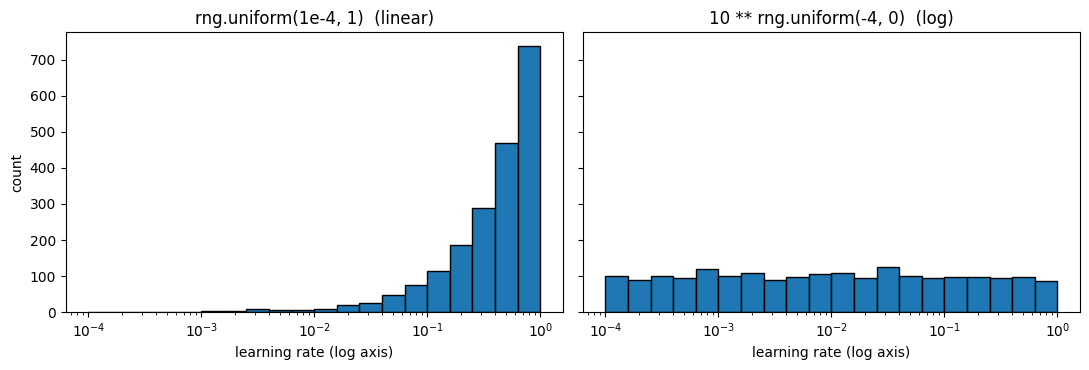

In [15]:
n = 2000
lin_samples = rng.uniform(1e-4, 1, size=n)                 # linear scale
log_samples = 10 ** rng.uniform(-4, 0, size=n)             # log scale
print(f"สัดส่วนที่ตกในช่วง [0.0001, 0.1): linear = {np.mean(lin_samples < 0.1):.3f} (สไลด์บอก ~10%) | log = {np.mean(log_samples < 0.1):.3f} (~75%)")

bins = np.logspace(-4, 0, 21)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=True)
for ax, samples, name in zip(axes, [lin_samples, log_samples], ["rng.uniform(1e-4, 1)  (linear)", "10 ** rng.uniform(-4, 0)  (log)"]):
    ax.hist(samples, bins=bins, edgecolor="k"); ax.set_xscale("log"); ax.set_xlabel("learning rate (log axis)"); ax.set_title(name)
axes[0].set_ylabel("count")
plt.tight_layout(); plt.show()

### coarse-to-fine (สไลด์ p.119)
รอบแรกสุ่มหยาบทั่วช่วงกว้าง พอเห็นว่าค่าดีๆ กระจุกอยู่แถวไหน รอบสองสุ่มละเอียดเฉพาะแถวนั้น
cell นี้เอา `lr` ที่ดีที่สุดจากตารางข้างบนเป็นศูนย์กลาง แล้วสุ่มอีก 5 ค่าในช่วง ±0.5 ทศวรรษ (คูณ/หารราว 3 เท่า) โดยตรึง hidden unit ไว้เท่าเดิม

In [16]:
best = search.iloc[0]
center = np.log10(best["lr"])
rows = []
for lr_i in 10 ** rng.uniform(center - 0.5, center + 0.5, size=5):       # ช่วงแคบรอบค่าที่ดีที่สุด
    model = NeuralNetwork([n_x, int(best["hidden"]), 1], lr=lr_i, epochs=150, optimizer="adam", batch_size=64).fit(X_tr_c, y_tr_c)
    rows.append({"lr": lr_i, "hidden": int(best["hidden"]), "val acc": model.evaluate(X_val_c, y_val_c)["accuracy"]})
fine = pd.DataFrame(rows).sort_values("val acc", ascending=False)
print(f"รอบหยาบดีที่สุด: lr = {best['lr']:.4f}, hidden = {int(best['hidden'])}, val acc = {best['val acc']:.3f}")
print("รอบละเอียด (lr ใน [%.4f, %.4f]):" % (10 ** (center - 0.5), 10 ** (center + 0.5)))
print(fine.round(4).to_string(index=False))

รอบหยาบดีที่สุด: lr = 0.0031, hidden = 22, val acc = 0.760
รอบละเอียด (lr ใน [0.0010, 0.0099]):
    lr  hidden  val acc
0.0083      22    0.770
0.0035      22    0.760
0.0038      22    0.760
0.0023      22    0.750
0.0022      22    0.745


### scikit-learn ทำให้ใน 5 บรรทัด: `RandomizedSearchCV`
`RandomizedSearchCV` สุ่ม hyperparameter `n_iter` ชุด และประเมินแต่ละชุดด้วย **k-fold cross-validation** (`cv=3` แบ่ง training set เป็น 3 ส่วน ผลัดกันเป็น validation — lab10 จะลงรายละเอียด)
`loguniform(1e-3, 1)` ของ scipy คือการสุ่ม log-scale แบบเดียวกับ `10 ** rng.uniform(-3, 0)`
เราใช้ `n_iter=6` และ `max_iter=150` ให้รันเร็ว (sklearn จะเตือนว่ายังไม่ converge — ปิดคำเตือนไว้เพราะตั้งใจ)

In [17]:
import warnings
from sklearn.exceptions import ConvergenceWarning
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform
warnings.filterwarnings("ignore", category=ConvergenceWarning)

space = {"learning_rate_init": loguniform(1e-3, 1), "hidden_layer_sizes": [(8,), (16,), (32,), (64,)]}
cv_search = RandomizedSearchCV(MLPClassifier(max_iter=150, random_state=463), space, n_iter=6, cv=3, random_state=463).fit(X_tr_c, y_tr_c)

print("best params:", cv_search.best_params_, f"| cv accuracy = {cv_search.best_score_:.3f} | val accuracy = {cv_search.score(X_val_c, y_val_c):.3f}")
cv_table = pd.DataFrame(cv_search.cv_results_)[["param_learning_rate_init", "param_hidden_layer_sizes", "mean_test_score"]]
cv_table.sort_values("mean_test_score", ascending=False).round(4)

best params: {'hidden_layer_sizes': (8,), 'learning_rate_init': np.float64(0.3724052620363955)} | cv accuracy = 0.733 | val accuracy = 0.715


,param_learning_rate_init,param_hidden_layer_sizes,mean_test_score
5,0.3724,"(8,)",0.7325
1,0.0034,"(16,)",0.7287
0,0.0023,"(8,)",0.7250
2,0.0035,"(64,)",0.7225
4,0.3450,"(8,)",0.7212
3,0.2558,"(64,)",0.7012


## ขั้นที่ 6 · เวอร์ชัน production ใน `nnlab`
โค้ดที่เราเพิ่งเขียนใน cell ด้านบนคือ "โค้ดเพื่อความเข้าใจ" — แยกทุกขั้นให้เห็น
ในการใช้งานจริง โค้ดเดียวกันถูกจัดเป็นฟังก์ชัน/คลาสใน `src/nnlab/nn.py` พร้อม docstring, type hints และ test
cell ถัดไปเรียกเวอร์ชัน production มาเทียบกับที่เราเขียนเอง (`l2`, `keep_prob` และ `early_stopping_patience` ของ `NeuralNetwork`) — ตัวเลขต้องตรงกัน
เปิดไฟล์ `src/nnlab/nn.py` ควบคู่กันเพื่อดูว่าโค้ด "ทดลอง" กลายเป็นโค้ด "ใช้งานจริง" ได้อย่างไร

In [18]:
# 1) l2: cost ที่ NeuralNetwork บันทึกใน history_ = BCE + (λ/2m) Σ‖W‖²_F ที่เราเขียนเอง (คำนวณจาก params_ สุดท้าย)
reg = l2_models[0.1]
A_reg, _ = forward(X_deck, reg.params_, reg.activations)
J_inline = compute_cost(A_reg, Y) + 0.1 / (2 * m) * sum(np.sum(v ** 2) for k, v in reg.params_.items() if k.startswith("W"))
assert np.isclose(J_inline, reg.history_["cost"][-1])
print(f"l2=0.1: cost สุดท้ายใน history_ {reg.history_['cost'][-1]:.6f} == สูตร inline {J_inline:.6f} ✓")

# 2) keep_prob: forward ตอนเทรนใช้ mask (สัดส่วนเปิด ≈ keep_prob) แต่ predict_proba ไม่ใช้ dropout → ค่าเดิมทุกครั้ง
dm = drop_models[0.5]
_, c_train = forward(X_deck, dm.params_, dm.activations, keep_prob=0.5, training=True, rng=rng)
p1, p2 = dm.predict_proba(X_val), dm.predict_proba(X_val)
print(f"keep_prob=0.5: mask ชั้น 1 เปิด {c_train[0]['D'].mean():.3f} ตอนเทรน | predict_proba เรียกซ้ำได้ค่าเดิม: {np.array_equal(p1, p2)} ✓")

# 3) early stopping: history ยาว stopped_epoch_ + 1 และจุดหยุด = epoch ที่ val cost ต่ำสุด + patience
val_es = np.array(es.history_["val_cost"])
assert len(val_es) == es.stopped_epoch_ + 1 and es.stopped_epoch_ - int(val_es.argmin()) == patience
print(f"early stopping: history ยาว {len(val_es)} = stopped_epoch_ {es.stopped_epoch_} + 1 | argmin val cost = {int(val_es.argmin())} = stopped − patience ✓")
print(reg)

l2=0.1: cost สุดท้ายใน history_ 0.219222 == สูตร inline 0.219222 ✓
keep_prob=0.5: mask ชั้น 1 เปิด 0.510 ตอนเทรน | predict_proba เรียกซ้ำได้ค่าเดิม: True ✓
early stopping: history ยาว 48 = stopped_epoch_ 47 + 1 | argmin val cost = 22 = stopped − patience ✓
NeuralNetwork(layer_sizes=[2, 64, 64, 1], activations=['relu', 'relu', 'sigmoid'], lr=0.3, epochs=1500, optimizer=SGD(lr=0.3))


## ★ Key Takeaways
- อ่าน bias/variance จากตัวเลข: train ต่ำ + val ต่ำ = underfit (bias); train สูง + val ต่ำกว่ามาก และ val cost เด้งขึ้น = overfit (variance) — ต้องมี validation set เสมอ
- L2: บวก $\frac{\lambda}{2m}\sum_l\|W^{[l]}\|_F^2$ ใน cost และ $\frac{\lambda}{m}W^{[l]}$ ใน $dW^{[l]}$ (ไม่แตะ $b$) — เท่ากับหด $W$ ด้วย $(1 - \frac{\alpha\lambda}{m})$ ทุก epoch (weight decay); torch ใช้ `weight_decay = λ/m`
- $\lambda$ ใหญ่ขึ้น → norm ของ $W$ เล็กลง → boundary เรียบขึ้น → val accuracy ดีขึ้นจนถึงจุดหนึ่งแล้วกลับไป underfit
- inverted dropout: `A * D / keep_prob` เฉพาะตอนเทรน (ค่าเฉลี่ยคงเดิม) ตอน test ไม่ทำอะไร; torch ใช้ `nn.Dropout(p=1-keep_prob)` และต้องสลับ `.train()`/`.eval()` เอง
- early stopping: หยุดเมื่อ val cost ไม่ดีขึ้นครบ patience epoch และคืน parameter ชุดที่ดีที่สุด — ง่าย แต่ปรับ "ลด cost" กับ "ลด overfit" แยกกันไม่ได้
- tune learning rate ก่อนเสมอ (p.116) ด้วย random search แบบ log-scale แล้ว coarse-to-fine; grid เสียงบให้ hyperparameter ที่ไม่สำคัญ — `RandomizedSearchCV` + `loguniform` ทำให้ใน 5 บรรทัด

## แบบฝึกหัด (ทำเอง)
ส่วนนี้ต้อง**เขียนโค้ดเอง** — แต่ละข้อมี 3 cell: โจทย์ (อ่านให้จบก่อน) → cell โครง (มี `raise NotImplementedError` ให้แทนที่ด้วยโค้ดของคุณ) → cell ตรวจคำตอบ
cell ตรวจคำตอบรันได้ทันที: ถ้ายังไม่ได้ทำจะขึ้น ⏳ ถ้าผิดจะขึ้น ✗ พร้อมคำใบ้ ถ้าถูกจะขึ้น ✓ PASS
ทำได้ไม่จำกัดรอบ แก้แล้วรัน cell โครงและ cell ตรวจซ้ำ ใช้ผลจาก cell ก่อนหน้าใน lab นี้ได้ทุกตัว

In [19]:
from nnlab.exercise import check, check_close, check_shape, summary, reset
reset()   # ล้างผลการตรวจเก่าใน kernel นี้

### แบบฝึกหัด 8.1 · regularization term ของ L2 จาก params dict
**เป้าหมาย:** เขียนฟังก์ชันคำนวณ (λ/2m)·Σ_l ‖W[l]‖²_F จาก dict ของ parameter (สูตร p.86) โดยรวมเฉพาะ W ไม่รวม b

**ขั้นตอน**
1. `params` เป็น dict แบบเดียวกับ `big.params_` ในขั้นที่ 2: key `'W1', 'b1', 'W2', ...` — วนทุก key แล้วเลือกเฉพาะที่ขึ้นต้นด้วย `'W'` (`k.startswith('W')`)
2. ของแต่ละ W คำนวณ `np.sum(W ** 2)` (Frobenius norm กำลังสอง) แล้วบวกรวมกันทุกชั้น
3. คูณด้วย `lam / (2 * m)` แล้วคืนเป็น `float` — เทียบกับ cell ขั้นที่ 2 ที่ทำทีละบรรทัดได้ (`frob`, `penalty`)

<details><summary>คำใบ้ (คลิกเพื่อเปิด)</summary>

- `for k, W in params.items(): if k.startswith('W'): total += np.sum(W ** 2)`
- อย่าลืมว่า m คือจำนวน sample (60) ไม่ใช่จำนวนชั้น
</details>

In [20]:
# --- แบบฝึกหัด 8.1: เขียนโค้ดของคุณใน cell นี้ (แทนที่ raise NotImplementedError) ---
def l2_term(params, lam, m):
    """regularization term (λ / 2m) Σ_l ‖W[l]‖²_F   params: {"W1": (n1, n0), "b1": (n1, 1), "W2": ...}   คืน float"""
    raise NotImplementedError("ยังไม่ได้ทำ")

# ตัวอย่างการเรียก (หลังเขียนเสร็จ): l2_term(params, 0.1, m)  → ต้องได้เท่ากับ penalty ในขั้นที่ 2

In [21]:
# --- ตรวจคำตอบ 8.1 (รันได้ทันที ไม่ต้องแก้) ---
check_close("8.1 λ=0.1 กับ params ของ network ใหญ่ ตรงกับ nnlab.losses.l2_penalty", lambda: l2_term(params, 0.1, m), l2_penalty(params, 0.1, m), hint="lam / (2 * m) คูณผลรวมของ np.sum(W ** 2) ทุกชั้น")
check_close("8.1 λ=1.0 กับ network [2,8,1]", lambda: l2_term(models["[2,8,1] just right"].params_, 1.0, m), l2_penalty(models["[2,8,1] just right"].params_, 1.0, m))
check_close("8.1 λ=0 → 0", lambda: l2_term(params, 0.0, m), 0.0)
params_big_b = {k: (v + 100.0 if k.startswith("b") else v) for k, v in params.items()}   # bias ใหญ่มาก แต่ต้องไม่มีผล
check_close("8.1 ไม่รวม bias (b ไม่ถูก regularize)", lambda: l2_term(params_big_b, 0.1, m), l2_penalty(params, 0.1, m), hint="เลือกเฉพาะ key ที่ขึ้นต้นด้วย 'W'")

⏳ 8.1 λ=0.1 กับ params ของ network ใหญ่ ตรงกับ nnlab.losses.l2_penalty: ยังไม่ได้ทำ
⏳ 8.1 λ=1.0 กับ network [2,8,1]: ยังไม่ได้ทำ
⏳ 8.1 λ=0 → 0: ยังไม่ได้ทำ
⏳ 8.1 ไม่รวม bias (b ไม่ถูก regularize): ยังไม่ได้ทำ


False

### แบบฝึกหัด 8.2 · inverted dropout เป็นฟังก์ชัน
**เป้าหมาย:** เขียน `apply_dropout(A, keep_prob, rng)` ที่สุ่มปิด unit แล้วชดเชย scale ตาม p.93-94 คืนทั้ง activation ที่ผ่าน dropout และ mask

**ขั้นตอน**
1. สร้าง mask `D = rng.random(A.shape) < keep_prob` (True = เปิด) — เหมือน cell แรกของขั้นที่ 3
2. ปิด unit ด้วยการคูณ mask แล้ว**หารด้วย keep_prob** (inverted dropout) เพื่อให้ค่าเฉลี่ยของ A คงเดิม
3. คืน `(A_drop, D)` — cell ตรวจจะดูว่า shape ถูก, สัดส่วนที่เปิด ≈ keep_prob, ช่องที่ปิดเป็น 0 และค่าเฉลี่ยของ A_drop ≈ ค่าเฉลี่ยของ A
4. ลองกับ `A1` (64, 60) จาก caches: `A_d, D_d = apply_dropout(A1, 0.8, rng)` แล้วพิมพ์ `A1.mean(), A_d.mean(), D_d.mean()`

<details><summary>คำใบ้ (คลิกเพื่อเปิด)</summary>

- `A * D / keep_prob` — mask boolean คูณกับ float ได้เลย (True = 1)
- ค่าเฉลี่ยของ A_drop ที่ keep_prob=0.5 ต้อง ≈ A.mean() ถ้าได้ครึ่งเดียวแปลว่าลืมหาร
</details>

In [22]:
# --- แบบฝึกหัด 8.2: เขียนโค้ดของคุณใน cell นี้ (แทนที่ raise NotImplementedError) ---
def apply_dropout(A, keep_prob, rng):
    """inverted dropout (p.93-94)   A: (n[l], m) activation ของ hidden layer   คืน (A_drop (n[l], m), D mask 0/1 shape เท่า A)"""
    raise NotImplementedError("ยังไม่ได้ทำ")

# ตัวอย่างการเรียก: A_d, D_d = apply_dropout(A1, 0.8, rng); print(A1.mean(), A_d.mean(), D_d.mean())

In [23]:
# --- ตรวจคำตอบ 8.2 (รันได้ทันที ไม่ต้องแก้) ---
rng_82 = np.random.default_rng(82)
A_82 = rng_82.random((200, 500)) + 0.5                    # (200, 500) ค่าบวกทั้งหมด (ไม่มีศูนย์จาก ReLU) mean ≈ 1
check_shape("8.2 A_drop shape เท่า A", lambda: apply_dropout(A_82, 0.8, rng_82)[0], (200, 500))
check_shape("8.2 mask shape เท่า A", lambda: apply_dropout(A_82, 0.8, rng_82)[1], (200, 500))
check("8.2 mask มีแต่ 0/1", lambda: np.isin(np.asarray(apply_dropout(A_82, 0.8, rng_82)[1], dtype=float), [0.0, 1.0]).all(), hint="D = rng.random(A.shape) < keep_prob")
check("8.2 สัดส่วนที่เปิด ≈ keep_prob (0.8)", lambda: abs(np.mean(apply_dropout(A_82, 0.8, rng_82)[1]) - 0.8) < 0.03, hint="เปรียบเทียบ < keep_prob ไม่ใช่ > keep_prob")
def _closed_zero_82():
    A_d, D = apply_dropout(A_82, 0.5, rng_82)
    return np.all(A_d[np.asarray(D) == 0] == 0)
check("8.2 ช่องที่ mask ปิดต้องเป็น 0", _closed_zero_82, hint="A * D")
check("8.2 ค่าเฉลี่ยคงเดิมที่ keep_prob=0.5 (inverted)", lambda: abs(apply_dropout(A_82, 0.5, rng_82)[0].mean() - A_82.mean()) < 0.03, hint="หารด้วย keep_prob หลังคูณ mask — ถ้าไม่หาร mean จะเหลือครึ่งเดียว")
check("8.2 keep_prob=1.0 → A ไม่เปลี่ยน", lambda: np.allclose(apply_dropout(A_82, 1.0, rng_82)[0], A_82))

⏳ 8.2 A_drop shape เท่า A: ยังไม่ได้ทำ
⏳ 8.2 mask shape เท่า A: ยังไม่ได้ทำ
⏳ 8.2 mask มีแต่ 0/1: ยังไม่ได้ทำ
⏳ 8.2 สัดส่วนที่เปิด ≈ keep_prob (0.8): ยังไม่ได้ทำ
⏳ 8.2 ช่องที่ mask ปิดต้องเป็น 0: ยังไม่ได้ทำ
⏳ 8.2 ค่าเฉลี่ยคงเดิมที่ keep_prob=0.5 (inverted): ยังไม่ได้ทำ
⏳ 8.2 keep_prob=1.0 → A ไม่เปลี่ยน: ยังไม่ได้ทำ


False

### แบบฝึกหัด 8.3 · dropout แรงเกินไป: keep_prob = 0.2
**เป้าหมาย:** เขียนฟังก์ชันเทรน network ใหญ่ด้วย keep_prob ที่กำหนด แล้วคืน train/val accuracy เพื่อดูว่าปิด unit 80% ทำให้เกิด bias หรือ variance

**ขั้นตอน**
1. สร้าง `NeuralNetwork([2, 64, 64, 1], lr=0.3, epochs=epochs, keep_prob=keep_prob)` แล้ว `fit(X_tr, y_tr, X_val, y_val)` — setting เดียวกับตาราง `drop_table` ในขั้นที่ 3
2. วัด accuracy ด้วย `model.evaluate(X_tr, y_tr)['accuracy']` และ `model.evaluate(X_val, y_val)['accuracy']`
3. คืน dict `{'train_acc': ..., 'val_acc': ..., 'model': model}`
4. หลังผ่าน ลองเรียก `train_keep_prob(0.2)` และ `train_keep_prob(1.0)` (เพิ่ม cell ใหม่) แล้วเทียบกับ `drop_table`: keep_prob=0.2 ทำให้ **train acc ตกด้วย** — นี่คืออาการของ bias สูง (underfit) ไม่ใช่ variance; ลองเพิ่ม `epochs` ดูว่าช่วยไหม

<details><summary>คำใบ้ (คลิกเพื่อเปิด)</summary>

- โครงเดียวกับ loop ใน cell `drop_models` ของขั้นที่ 3 แต่ห่อเป็นฟังก์ชันและคืน dict
- ผลของ seed: `NeuralNetwork` ใช้ seed=463 เสมอ → เรียกด้วย setting เดิมได้ตัวเลขเดิมเป๊ะ
</details>

In [24]:
# --- แบบฝึกหัด 8.3: เขียนโค้ดของคุณใน cell นี้ (แทนที่ raise NotImplementedError) ---
def train_keep_prob(keep_prob, epochs=1500):
    """เทรน [2, 64, 64, 1] (lr=0.3) บน X_tr, y_tr ด้วย dropout keep_prob แล้วคืน {"train_acc": float, "val_acc": float, "model": NeuralNetwork}"""
    raise NotImplementedError("ยังไม่ได้ทำ")

# ตัวอย่างการเรียก: r = train_keep_prob(0.2); print(r["train_acc"], r["val_acc"])

In [25]:
# --- ตรวจคำตอบ 8.3 (รันได้ทันที ไม่ต้องแก้) ---
from functools import lru_cache

@lru_cache(maxsize=None)                                  # เทรนแต่ละ keep_prob ครั้งเดียว แล้วใช้ซ้ำในทุก check
def _run_83(kp):
    return train_keep_prob(kp)

_row_83 = drop_table[drop_table["keep_prob"] == 1.0].iloc[0]
check("8.3 คืน dict ที่มี train_acc และ val_acc", lambda: isinstance(_run_83(1.0), dict) and {"train_acc", "val_acc"} <= set(_run_83(1.0)))
check_close("8.3 keep_prob=1.0: train acc ตรงกับ drop_table (seed เดียวกัน)", lambda: _run_83(1.0)["train_acc"], float(_row_83["train acc"]), atol=1e-3, hint="ใช้ lr=0.3, epochs=1500 และ fit(X_tr, y_tr, X_val, y_val) เหมือนขั้นที่ 3")
check_close("8.3 keep_prob=1.0: val acc ตรงกับ drop_table", lambda: _run_83(1.0)["val_acc"], float(_row_83["val acc"]), atol=1e-3, hint="val acc ต้องวัดบน X_val, y_val")
check("8.3 keep_prob=0.2: train acc ต่ำกว่า keep_prob=1.0 (ปิด 80% → underfit)", lambda: _run_83(0.2)["train_acc"] < _run_83(1.0)["train_acc"])
check("8.3 keep_prob=0.2: val acc ยัง ≥ 0.70 (ยังเรียนรู้ได้)", lambda: _run_83(0.2)["val_acc"] >= 0.70)

⏳ 8.3 คืน dict ที่มี train_acc และ val_acc: ยังไม่ได้ทำ
⏳ 8.3 keep_prob=1.0: train acc ตรงกับ drop_table (seed เดียวกัน): ยังไม่ได้ทำ
⏳ 8.3 keep_prob=1.0: val acc ตรงกับ drop_table: ยังไม่ได้ทำ
⏳ 8.3 keep_prob=0.2: train acc ต่ำกว่า keep_prob=1.0 (ปิด 80% → underfit): ยังไม่ได้ทำ
⏳ 8.3 keep_prob=0.2: val acc ยัง ≥ 0.70 (ยังเรียนรู้ได้): ยังไม่ได้ทำ


False

### แบบฝึกหัด 8.4 · สุ่ม learning rate แบบ log-scale
**เป้าหมาย:** เขียน `sample_log_uniform(low, high, size, rng)` ที่สุ่มค่าในช่วง [low, high] โดยให้แต่ละทศวรรษมีโอกาสเท่ากัน (p.120) แล้วตรวจด้วยสัดส่วน

**ขั้นตอน**
1. แปลงขอบเป็น exponent: `lo = np.log10(low)`, `hi = np.log10(high)` (เช่น 1e-4 → -4, 1 → 0)
2. สุ่ม exponent แบบ uniform `rng.uniform(lo, hi, size=size)` แล้วยกกำลัง `10 ** exponent` — เหมือน `log_samples` ในขั้นที่ 5 แต่ใช้กับช่วงใดก็ได้
3. คืน array shape `(size,)` — cell ตรวจจะนับว่าสัดส่วนที่ต่ำกว่า 1e-3 ในช่วง [1e-4, 1] ≈ 25% (ถ้าสุ่ม linear จะได้ ~0.1%)

<details><summary>คำใบ้ (คลิกเพื่อเปิด)</summary>

- `10 ** rng.uniform(np.log10(low), np.log10(high), size=size)`
- ช่วง [1e-4, 1] มี 4 ทศวรรษ → แต่ละทศวรรษ 25%; [0.01, 10] มี 3 ทศวรรษ → ทศวรรษแรก (0.01-0.1) ได้ 1/3
</details>

In [26]:
# --- แบบฝึกหัด 8.4: เขียนโค้ดของคุณใน cell นี้ (แทนที่ raise NotImplementedError) ---
def sample_log_uniform(low, high, size, rng):
    """สุ่ม size ค่าใน [low, high] แบบ log-uniform (แต่ละทศวรรษได้โอกาสเท่ากัน) คืน array (size,)"""
    raise NotImplementedError("ยังไม่ได้ทำ")

# ตัวอย่างการเรียก: s = sample_log_uniform(1e-4, 1, 4000, rng); print(np.mean(s < 1e-3), np.mean(s < 0.1))

In [27]:
# --- ตรวจคำตอบ 8.4 (รันได้ทันที ไม่ต้องแก้) ---
rng_84 = np.random.default_rng(84)
check_shape("8.4 shape (4000,)", lambda: np.asarray(sample_log_uniform(1e-4, 1.0, 4000, rng_84)), (4000,))
check("8.4 ทุกค่าอยู่ใน [1e-4, 1]", lambda: np.min(sample_log_uniform(1e-4, 1.0, 4000, rng_84)) >= 1e-4 and np.max(sample_log_uniform(1e-4, 1.0, 4000, rng_84)) <= 1.0, hint="10 ** (exponent ใน [-4, 0]) อยู่ใน [1e-4, 1] เสมอ")
check("8.4 สัดส่วนที่ < 1e-3 ≈ 25% (±6%)", lambda: abs(np.mean(np.asarray(sample_log_uniform(1e-4, 1.0, 4000, rng_84)) < 1e-3) - 0.25) < 0.06, hint="สุ่ม exponent ด้วย uniform แล้ว 10 ** exponent — ถ้าสุ่มค่าตรงๆ จะได้เกือบ 0%")
check("8.4 สัดส่วนที่ < 0.1 ≈ 75% (±6%)", lambda: abs(np.mean(np.asarray(sample_log_uniform(1e-4, 1.0, 4000, rng_84)) < 0.1) - 0.75) < 0.06)
check("8.4 ใช้กับช่วง [0.01, 10] ได้: ~1/3 ต่ำกว่า 0.1", lambda: abs(np.mean(np.asarray(sample_log_uniform(0.01, 10.0, 6000, rng_84)) < 0.1) - 1 / 3) < 0.06, hint="อย่า hardcode -4 และ 0 — ใช้ np.log10(low), np.log10(high)")

⏳ 8.4 shape (4000,): ยังไม่ได้ทำ
⏳ 8.4 ทุกค่าอยู่ใน [1e-4, 1]: ยังไม่ได้ทำ
⏳ 8.4 สัดส่วนที่ < 1e-3 ≈ 25% (±6%): ยังไม่ได้ทำ
⏳ 8.4 สัดส่วนที่ < 0.1 ≈ 75% (±6%): ยังไม่ได้ทำ
⏳ 8.4 ใช้กับช่วง [0.01, 10] ได้: ~1/3 ต่ำกว่า 0.1: ยังไม่ได้ทำ


False

### สรุปผลแบบฝึกหัด
รัน cell นี้หลังทำครบทุกข้อ (รัน cell ตรวจของทุกข้อก่อน)

In [28]:
summary()

สรุป: PASS 0/21 · FAIL 0 · ยังไม่ได้ทำ 21


{'pass': 0, 'fail': 0, 'todo': 21, 'error': 0}